## Understanding Softmax Regression

### Step 1: The Intuition - Why Sigmoid Falls Short for Multi-Class Classification

In binary classification, the Sigmoid function is a perfect fit. It outputs a single probability ($\hat{y}$) for one class, and the probability for the other class is simply $1 - \hat{y}$. This ensures the probabilities always sum to 1.

However, when we try to extend this to *multiple independent Sigmoid neurons* for more than two classes (e.g., Cat, Dog, Bird), a significant problem arises: **the probabilities will not necessarily add up to 1.**

**Consider this scenario:**

Imagine a model that outputs the following probabilities for an image:
*   Probability of Cat = 0.80
*   Probability of Dog = 0.70
*   Probability of Bird = 0.40

The sum of these probabilities is 1.90! In probability theory, this is invalid. This happens because each Sigmoid neuron operates in isolation; they don't 'talk' to each other or enforce a collective sum of 1.

To handle multi-class problems correctly, we need a function that:
1.  Considers all class scores simultaneously.
2.  Forces them to compete against each other.
3.  Scales them so that the final outputs are valid probabilities that sum up to exactly 1.0.

**This is where Softmax comes in.**

### Step 2: The Mathematics of Softmax

Instead of just one score, Softmax Regression first calculates a raw linear score ($z$) for every single class independently. If you have, for instance, 3 features and 3 classes, you will have 3 separate linear equations running in parallel to generate these scores:

$$z_1 = w_{11}x_1 + w_{12}x_2 + b_1 \quad \text{(Score for Cat)}$$
$$z_2 = w_{21}x_1 + w_{22}x_2 + b_2 \quad \text{(Score for Dog)}$$
$$z_3 = w_{31}x_1 + w_{32}x_2 + b_3 \quad \text{(Score for Bird)}$$

These raw scores are often called **logits**. Once we have these logits, we pass all of them into the Softmax Function:

$$\hat{y}_k = \sigma(Z)_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}$$

Let's break down how this mathematical transformation works:

*   **The Exponential Exponent ($e^z$):** We raise the mathematical constant $e$ (approximately 2.718) to the power of each raw score ($z$). This step is crucial because:
    *   It converts any negative scores into positive values.
    *   It *aggressively amplifies* larger scores, making the biggest score stand out even more. This helps a 'clear winner' class to emerge.

*   **The Normalization Sum ($\sum e^z$):** We then sum up all these exponential scores from *all* classes. This sum will be in the denominator of our final calculation.

*   **The Division:** Finally, for each class, we divide its individual exponential score by the total sum calculated in the previous step. This division acts like a mathematical 'straightjacket,' forcing the final outputs ($\hat{y}_k$) to perfectly balance out and sum up to precisely 1.0 across all classes. Each $\hat{y}_k$ now represents the predicted probability for class $k$.

### Step 3: What is Polynomial Logistic Regression?

Just like its cousin, standard Linear Regression, Softmax Regression inherently creates **straight lines** (or hyperplanes in higher dimensions) to separate data classes. This works well if your classes are linearly separable.

However, many real-world datasets have complex, non-linear arrangements (e.g., data points forming concentric circles, moons, or interlocking spirals). In such cases, a simple straight-line decision boundary will perform catastrophically.

To overcome this limitation, we introduce **Polynomial Features**. This technique involves taking our original features (e.g., $x_1, x_2$) and mathematically generating higher-order terms and interactions from them. Examples include:
*   Squared terms: $x_1^2, x_2^2$
*   Interaction terms: $x_1x_2$
*   Higher powers: $x_1^3, x_2^3$, and so on.

When Softmax Regression operates on these newly generated polynomial features, its decision boundaries, which are still 'straight' in the higher-dimensional feature space, translate into **curves, loops, and waves** in the original 2D (or 3D) data space. This powerful transformation allows our otherwise single-neuron architecture to capture and delineate incredibly complex non-linear classification gaps, significantly enhancing its ability to model intricate data patterns.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


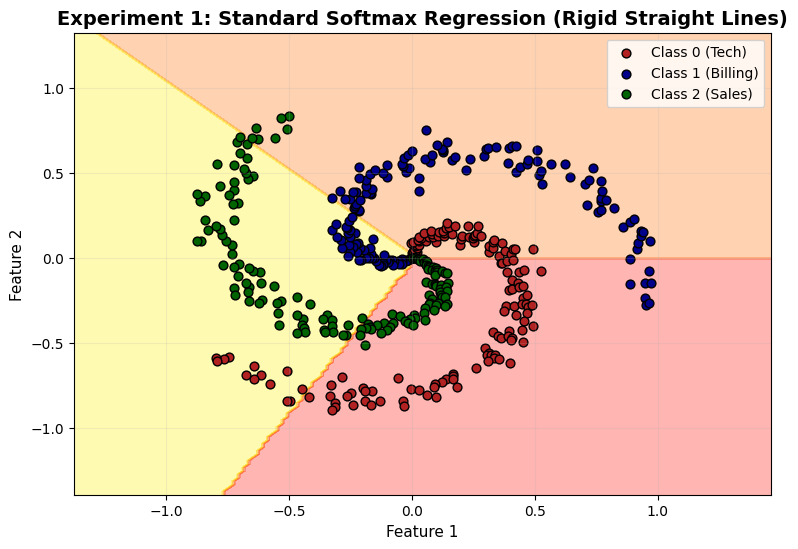

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


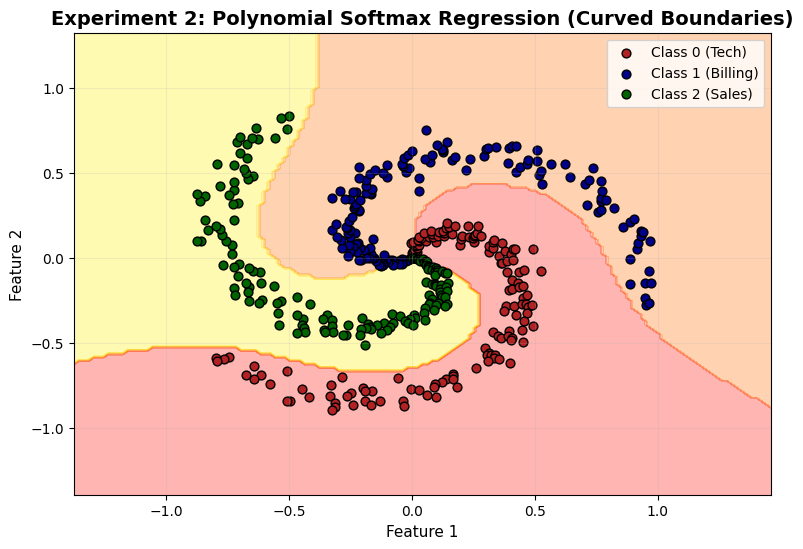

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# GENERATE COMPLEX MULTI-CLASS SPIRAL DATA
def create_spiral_data(samples_per_class=100, classes=3):
    np.random.seed(42)
    N = samples_per_class
    D = 2 # 2D features
    X = np.zeros((N * classes, D))
    y = np.zeros(N * classes, dtype='uint8')

    for j in range(classes):
        ix = range(N * j, N * (j + 1))
        r = np.linspace(0.0, 1, N) # radius
        t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2 # theta
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j
    return X, y

X, y = create_spiral_data(samples_per_class=150, classes=3)

# Helper function to plot decision boundaries
def plot_decision_mesh(model, title):
    plt.figure(figsize=(9, 6))

    # Create meshgrid boundaries
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict over grid mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot contoured surface
    plt.contourf(xx, yy, Z, cmap='autumn', alpha=0.3)

    # Scatter data clusters
    colors = ['firebrick', 'darkblue', 'darkgreen']
    labels = ['Class 0 (Tech)', 'Class 1 (Billing)', 'Class 2 (Sales)']
    for i in range(3):
        plt.scatter(X[y==i][:, 0], X[y==i][:, 1], color=colors[i], label=labels[i], edgecolors='k', s=40)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Feature 1', fontsize=11)
    plt.ylabel('Feature 2', fontsize=11)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# ==========================================
# EXPERIMENT 1: STANDARD LINEAR SOFTMAX REGRESSION
# ==========================================
# 'multinomial' flags scikit-learn to utilize the Softmax function engine
linear_softmax = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
linear_softmax.fit(X, y)

plot_decision_mesh(linear_softmax, "Experiment 1: Standard Softmax Regression (Rigid Straight Lines)")

# ==========================================
# EXPERIMENT 2: POLYNOMIAL SOFTMAX REGRESSION
# ==========================================
# We pack PolynomialFeatures into a pipeline to dynamically curve the multi-class space
polynomial_softmax = Pipeline([
    ('poly', PolynomialFeatures(degree=4)),      # Try changing degree to 3 or 5!
    ('scaler', StandardScaler()),                 # Keeps expanded numbers scaled
    ('softmax', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000))
])
polynomial_softmax.fit(X, y)

plot_decision_mesh(polynomial_softmax, "Experiment 2: Polynomial Softmax Regression (Curved Boundaries)")

## What you will notice in your graphs:
- Graph 1: You will see three rigid straight lines attempting to slice through the spiral. Because the data spirals around the origin, standard Softmax is fundamentally trapped by its linear boundaries, leading to high training error.

- Graph 2: The decision boundary magically warps into a fluid, curved pinwheel shape. By transforming the inputs into a higher dimensional space using PolynomialFeatures(degree=4), the Softmax model effortlessly wraps around the true underlying curvature of the data.